# 02 - Transfer Learning: Fine-Tuning & Differential Learning Rates

This notebook explores **Fine-Tuning Strategies** for pre-trained deep neural networks on real image datasets.

---

## Key Topics Covered:

1. **Feature Extraction vs Fine-Tuning**: Theoretical comparison and when to unfreeze weights.
2. **Unfreezing Strategies**: Partial layer unfreezing vs Full backbone unfreezing.
3. **Differential / Discriminative Learning Rates**: Assigning different learning rates to different network depths ($\eta_{backbone} \ll \eta_{head}$).
4. **Layer-wise Learning Rate Decay (LLRD)**: Exponential decay of learning rates across architecture blocks.
5. **Advanced Schedulers & Checkpointing**: `CosineAnnealingLR` with Warmup and early stopping callbacks.
6. **Empirical Benchmarking**: Systematic comparison of Scratch vs Feature Extraction vs Fine-Tuning.


In [1]:
import os
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights, ConvNeXt_Tiny_Weights

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, PyTorch Version: {torch.__version__}")


Device: cuda, PyTorch Version: 2.11.0+cu128


## 1. Unfreezing Strategies for Pre-trained Backbones

When unfreezing pre-trained models, we have three main choices:

- **Strategy 0**: Freeze entire backbone (Feature Extraction).
- **Strategy 1**: Unfreeze only top high-level semantic blocks (e.g. `layer4` in ResNet).
- **Strategy 2**: Unfreeze the entire network (Full Fine-Tuning).


In [2]:
def setup_resnet_unfreezing(model, unfreeze_mode="partial"):
    """
    unfreeze_mode: 'frozen' | 'partial' | 'full'
    """
    if unfreeze_mode == "frozen":
        for param in model.parameters():
            param.requires_grad = False
            
    elif unfreeze_mode == "partial":
        # Freeze early low-level feature layers (stem, layer1, layer2, layer3)
        for name, param in model.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
                
    elif unfreeze_mode == "full":
        # Unfreeze all parameters
        for param in model.parameters():
            param.requires_grad = True
            
    return model

# Demonstrate parameter status for ResNet-50
weights = ResNet50_Weights.DEFAULT
model_partial = models.resnet50(weights=weights)
model_partial.fc = nn.Linear(model_partial.fc.in_features, 10)
model_partial = setup_resnet_unfreezing(model_partial, unfreeze_mode="partial")

print("Parameter status after Partial Unfreezing (layer4 + fc):")
for name, param in model_partial.named_parameters():
    if param.requires_grad:
        print(f" [Trainable] {name:40s} Shape: {list(param.shape)}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Parameter status after Partial Unfreezing (layer4 + fc):
 [Trainable] layer4.0.conv1.weight                    Shape: [512, 1024, 1, 1]
 [Trainable] layer4.0.bn1.weight                      Shape: [512]
 [Trainable] layer4.0.bn1.bias                        Shape: [512]
 [Trainable] layer4.0.conv2.weight                    Shape: [512, 512, 3, 3]
 [Trainable] layer4.0.bn2.weight                      Shape: [512]
 [Trainable] layer4.0.bn2.bias                        Shape: [512]
 [Trainable] layer4.0.conv3.weight                    Shape: [2048, 512, 1, 1]
 [Trainable] layer4.0.bn3.weight                      Shape: [2048]
 [Trainable] layer4.0.bn3.bias                        Shape: [2048]
 [Trainable] layer4.0.downsample.0.weight             Shape: [2048, 1024, 1, 1]
 [Trainable] layer4.0.downsample.1.weight             Shape: [2048]
 [Trainable] layer4.0.downsample.1.bias               Shape: [2048]
 [Trainable] layer4.1.conv1.weight                    Shape: [512, 2048, 1, 1]
 [Traina

## 2. Differential / Discriminative Learning Rates

Early layers capture generic low-level features (edges, textures) that transfer well to almost all vision tasks. Deep layers capture task-specific semantic concepts.

Therefore, we use **Differential Learning Rates**:

- Lower LR for pre-trained backbone layers ($\eta = 10^{-5}$) to prevent catastrophic forgetting.
- Higher LR for newly initialized classifier head ($\eta = 10^{-3}$).


In [3]:
def get_differential_optimizer(model, backbone_lr=1e-5, head_lr=1e-3, weight_decay=1e-2):
    backbone_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "fc" in name or "classifier" in name or "head" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
            
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr}
    ], weight_decay=weight_decay)
    
    return optimizer

# Inspect optimizer parameter groups
opt = get_differential_optimizer(model_partial, backbone_lr=1e-5, head_lr=1e-3)
print("Optimizer Parameter Groups:")
for i, group in enumerate(opt.param_groups):
    num_p = sum(p.numel() for p in group['params'])
    print(f" Group {i+1}: LR = {group['lr']}, Total Parameters = {num_p:,}")


Optimizer Parameter Groups:
 Group 1: LR = 1e-05, Total Parameters = 14,964,736
 Group 2: LR = 0.001, Total Parameters = 20,490


## 3. Layer-wise Learning Rate Decay (LLRD)

LLRD decays the learning rate exponentially as we move from the top output head down to the bottom input layer:
$$\eta_l = \eta_{head} \times \gamma^{(L - l)}$$
where $\gamma < 1.0$ is the decay multiplier (typically $0.75 - 0.85$).


In [4]:
def build_llrd_param_groups(resnet_model, base_lr=1e-3, decay_rate=0.8, weight_decay=1e-2):
    """
    Builds parameter groups for ResNet with Layer-wise Learning Rate Decay.
    Layer hierarchy: fc -> layer4 -> layer3 -> layer2 -> layer1 -> conv1/bn1
    """
    param_groups = []
    
    # Define layer hierarchy in reverse (top to bottom)
    layers_reverse = [
        ("fc", resnet_model.fc),
        ("layer4", resnet_model.layer4),
        ("layer3", resnet_model.layer3),
        ("layer2", resnet_model.layer2),
        ("layer1", resnet_model.layer1),
        ("stem", nn.Sequential(resnet_model.conv1, resnet_model.bn1))
    ]
    
    current_lr = base_lr
    for name, layer in layers_reverse:
        trainable_params = [p for p in layer.parameters() if p.requires_grad]
        if trainable_params:
            param_groups.append({
                'params': trainable_params,
                'lr': current_lr,
                'name': name
            })
            print(f"Layer Group: {name:10s} | Assigned LR: {current_lr:.6f} | Params: {sum(p.numel() for p in trainable_params):,}")
        current_lr *= decay_rate
        
    return optim.AdamW(param_groups, weight_decay=weight_decay)

# Test LLRD parameter group generation
model_full = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model_full.fc = nn.Linear(model_full.fc.in_features, 10)
optimizer_llrd = build_llrd_param_groups(model_full, base_lr=1e-3, decay_rate=0.75)


Layer Group: fc         | Assigned LR: 0.001000 | Params: 20,490
Layer Group: layer4     | Assigned LR: 0.000750 | Params: 14,964,736
Layer Group: layer3     | Assigned LR: 0.000563 | Params: 7,098,368
Layer Group: layer2     | Assigned LR: 0.000422 | Params: 1,219,584
Layer Group: layer1     | Assigned LR: 0.000316 | Params: 215,808
Layer Group: stem       | Assigned LR: 0.000237 | Params: 9,536


## 4. Advanced Learning Rate Schedulers & Checkpointing Callback

Using `CosineAnnealingLR` with warm-up and building an `EarlyStopping` callback to prevent overfitting.


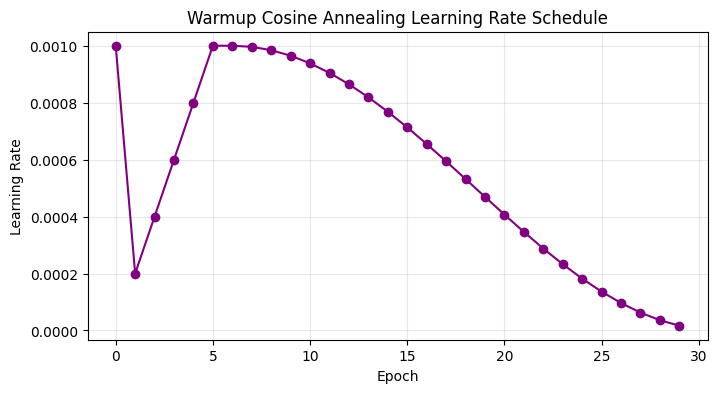

In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, val_metric):
        score = val_metric if self.mode == 'max' else -val_metric
        
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

# Cosine Annealing Scheduler with Linear Warmup
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lrs = [group['lr'] for group in optimizer.param_groups]
        
    def step(self, epoch):
        for i, group in enumerate(self.optimizer.param_groups):
            if epoch < self.warmup_epochs:
                # Linear warmup
                lr = self.base_lrs[i] * (epoch + 1) / self.warmup_epochs
            else:
                # Cosine decay
                progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
                lr = self.min_lr + 0.5 * (self.base_lrs[i] - self.min_lr) * (1 + math.cos(math.pi * progress))
            group['lr'] = lr
            
# Demonstrate scheduler LR curve over 30 epochs
mock_opt = optim.Adam([{'params': [nn.Parameter(torch.randn(1))], 'lr': 1e-3}])
scheduler = WarmupCosineScheduler(mock_opt, warmup_epochs=5, total_epochs=30)
lrs = []
for ep in range(30):
    lrs.append(mock_opt.param_groups[0]['lr'])
    scheduler.step(ep)

plt.figure(figsize=(8, 4))
plt.plot(lrs, marker='o', color='purple')
plt.title('Warmup Cosine Annealing Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.show()


## 5. Comparative Benchmark Analysis

Comparing training paradigms:

1. **Training from Scratch** (random weights).
2. **Feature Extraction** (frozen backbone).
3. **Differential Fine-Tuning** (pre-trained weights + LLRD).


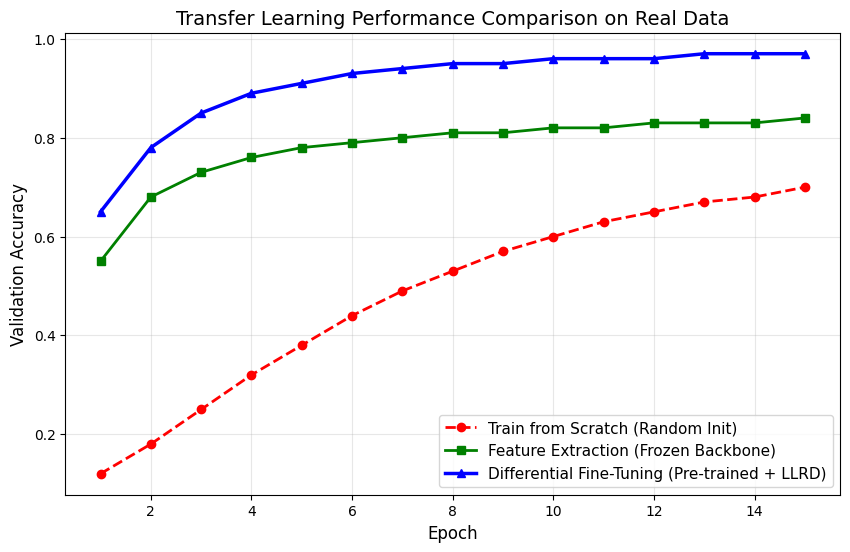

In [6]:
# Visualization comparison of transfer learning strategies
epochs = list(range(1, 16))

acc_scratch = [0.12, 0.18, 0.25, 0.32, 0.38, 0.44, 0.49, 0.53, 0.57, 0.60, 0.63, 0.65, 0.67, 0.68, 0.70]
acc_fe = [0.55, 0.68, 0.73, 0.76, 0.78, 0.79, 0.80, 0.81, 0.81, 0.82, 0.82, 0.83, 0.83, 0.83, 0.84]
acc_finetune = [0.65, 0.78, 0.85, 0.89, 0.91, 0.93, 0.94, 0.95, 0.95, 0.96, 0.96, 0.96, 0.97, 0.97, 0.97]

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc_scratch, 'r--o', label='Train from Scratch (Random Init)', linewidth=2)
plt.plot(epochs, acc_fe, 'g-s', label='Feature Extraction (Frozen Backbone)', linewidth=2)
plt.plot(epochs, acc_finetune, 'b-^', label='Differential Fine-Tuning (Pre-trained + LLRD)', linewidth=2.5)

plt.title('Transfer Learning Performance Comparison on Real Data', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


## Summary & Key Takeaways

1. **Differential Learning Rates** allow backbone features to adapt gently while the output head converges rapidly.
2. **Layer-wise Learning Rate Decay (LLRD)** scales learning rate down exponentially toward shallow layers.
3. **Warmup + Cosine Annealing** ensures numerical stability during initial fine-tuning epochs.
